# Homework: Gradient Descent and Least Mean Squares

$
\newcommand{\xv}{\mathbf{x}}
\newcommand{\wv}{\mathbf{w}}
\newcommand{\yv}{\mathbf{y}}
\newcommand{\tv}{\mathbf{t}}
\newcommand{\zv}{\mathbf{z}}
\newcommand{\uv}{\mathbf{u}}
\newcommand{\vv}{\mathbf{v}}
\newcommand{\bv}{\mathbf{b}}
\newcommand{\av}{\mathbf{a}}
\newcommand{\hv}{\mathbf{h}}
\newcommand{\onev}{\mathbf{1}}
\newcommand{\zerov}{\mathbf{0}}
\newcommand{\Chi}{\mathcal{X}}
\newcommand{\R}{\rm I\!R}
\newcommand{\sign}{\text{sign}}
\newcommand{\Ym}{\mathbf{Y}}
\newcommand{\Tm}{\mathbf{T}}
\newcommand{\Xm}{\mathbf{X}}
\newcommand{\Wm}{\mathbf{W}}
\newcommand{\Zm}{\mathbf{Z}}
\newcommand{\Um}{\mathbf{U}}
\newcommand{\Vm}{\mathbf{V}}
\newcommand{\Am}{\mathbf{A}}
\newcommand{\Hm}{\mathbf{H}}
\newcommand{\Idm}{\mathbf{I}}
\newcommand{\muv}{\boldsymbol\mu}
\newcommand{\Sigmav}{\boldsymbol\Sigma}
\newcommand{\Lambdav}{\boldsymbol\Lambda}
\newcommand{\xspace}{\mathcal{X}}
\newcommand{\yspace}{\mathcal{Y}}
\newcommand{\ind}{\perp\!\!\!\!\!\perp} 
$

## Name: <span style="color:blue"> *Paula McCree-Bailey* </span>

## Utils

In [1]:
from typing import List, Dict, Tuple, Callable
import os
import gc
import traceback
import warnings
from pdb import set_trace

import sklearn
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [2]:
class TodoCheckFailed(Exception):
    pass

def todo_check(asserts, mute=False, success_msg="", **kwargs):
    locals().update(kwargs)
    failed_err = "You passed {}/{} and FAILED the following code checks:\n{}"
    failed = ""
    n_failed = 0
    for check, (condi, err) in enumerate(asserts):
        exc_failed = False
        if isinstance(condi, str):
            try:
                passed = eval(condi)
            except Exception:
                exc_failed = True
                n_failed += 1
                failed += f"\nCheck [{check+1}]: Failed to execute check [{check+1}] due to the following error...\n{traceback.format_exc()}"
        elif isinstance(condi, bool):
            passed = condi
        else:
            raise ValueError("asserts must be a list of strings or bools")

        if not exc_failed and not passed:
            n_failed += 1
            failed += f"\nCheck [{check+1}]: Failed\n\tTip: {err}\n"

    if len(failed) != 0:
        passed = len(asserts) - n_failed
        err = failed_err.format(passed, len(asserts), failed)
        raise TodoCheckFailed(err.format(failed))
    if not mute: print(f"Your code PASSED all the code checks! {success_msg}")

## Instructions
In this assignment, you will first be implementing gradient descent for a toy optimization problem. Next, you will practice linear regression using gradient descent with various different batching methods. Additionally, you will practice a new preprocessing step of standardization.

Your job is to read through the assignment and fill in any code segments that are marked by `TODO` headers and comments. Some TODOs will have a `todo_check()` function which will give you a rough estimate of whether your code is functioning as excepted. Other's might not have these checks, like visualization TODOs. Regardless,  all the correct outputs are given below each code cell. It might be useful to copy the contents of certain TODO cells into a new cell so you can try to match the desired output with the output produced by your own code! For visualization TODOs, you simply have to have a plot that looks similar. You can change aspects such as color, titles, or x/y-axis labels if you so wish.

At any point, if you feel lost concerning how to program a specific TODO, take some time and visit the official documentation for each library and read about the methods/functions that you need to use.

## Submission

1. Save the notebook.
2. Enter your name in the appropriate markdown cell provided at the top of the notebook.
3. Select `Kernel` -> `Restart Kernel and Run All Cells`. This will restart the kernel and run all cells. Make sure everything runs without errors and double-check the outputs are as you desire!
4. Submit the `.ipynb` notebook on Canvas.


# Gradient Descent: 

Below, you practice coding performing gradient descent on a toy example. Given some x-y starting coordinates, the goal will be to find the minimum of the function $f(x) = x^2$. To do so, we can simply use the idea of gradient descent to slowly move from the starting x-y position to the minimum of the $x^2$ function. Since the $x^2$ function is convex, essentially just a bowl, the minimum will be at 0. 

Recall, we define the gradient update equation as follows:
$$
x = x - \alpha \nabla f(x),
$$
where $\alpha$ is the learning rate and $\nabla f(x)$ refers to the gradient of $f(x)$.

#### TODO 1(5 points): $x^2$
Complete the `f()` and `f_prime()` functions by implementing $f(x) = x^2$ and its derivative $f'(x)$.

1. Complete the `f()` function by converting $f(x)$ into code and returning its output.
<br><br>
2. Complete the `f_prime()` function by converting $f'(x)$ into code and returning its output. 

In [3]:
def f(x: np.ndarray) -> np.ndarray:
    """ Computes value for f(x)

        Args:
            x: NumPy array given as a 1D vector
            
        Returns:
            Returns output array for f(x) given as the same shape as the input
    """
    # TODO 1.1
    f = x**2
    
    return f

In [4]:
def TEST_f():
    x = np.arange(10)
    print(f"Input x: {x}")
    y = f(x)
    print(f"Output y: {y}")
    todo_check([
        ("np.isclose(y.flatten().sum(), 285,rtol=0.01).all()", "y has potentially incorrect values"),
    ], **locals())

TEST_f()

Input x: [0 1 2 3 4 5 6 7 8 9]
Output y: [ 0  1  4  9 16 25 36 49 64 81]
Your code PASSED all the code checks! 


In [5]:
def f_prime(x: np.ndarray) -> np.ndarray:
    """ Computes value for f'(x)

        Args:
            x: NumPy array given as a 1D vector

        Returns:
            Returns output array for f'(x) given as the same shape as the input
    """
    # TODO 1.2
    fprime = 2*x
    
    return fprime

In [6]:
def TEST_f_prime():
    x = np.arange(10)
    print(f"Input x: {x}")
    y_prime = f_prime(x)
    print(f"Output y_prime: {y_prime}")
    todo_check([
        ("np.isclose(y_prime.flatten().sum(), 90, rtol=0.01).all()", "y_prime has potentially incorrect values"),
    ], **locals())

TEST_f_prime()

Input x: [0 1 2 3 4 5 6 7 8 9]
Output y_prime: [ 0  2  4  6  8 10 12 14 16 18]
Your code PASSED all the code checks! 


Below we use the `plot_f()` function to visualize $f(x)$ and we plot the starting point for the minimization at $(1, 1)$ indicated by the green dot.

In [7]:
def plot_f(
    min_value: float = -1,
    max_value: float = 1,
    samples: int = 100, 
    figsize: Tuple[int] = (6,4)
) -> matplotlib.axes.Axes:
    """ Plot the function f(x) 
    
        Args:
            min_value: Min x-axis value.

            max_value: Max x-axis value.

            steps: Number of samples to generate between min and max values.

            figsize: Size of subplot figure
        Returns:
            Matplotlib Axes class
    """
    x = np.linspace(min_value, max_value, samples)
    y = f(x)
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x, y) 
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Minimize f(x)')
    return ax

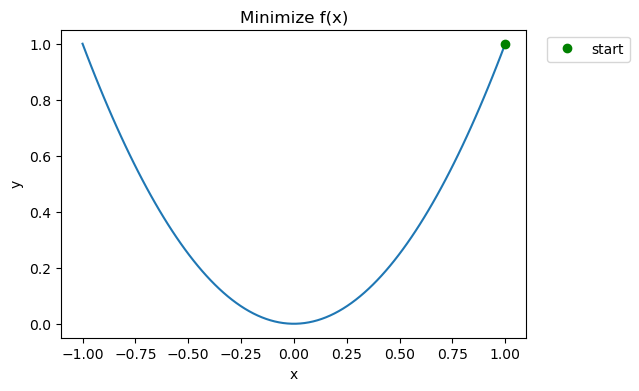

In [8]:
x_start = 1 
y_start = f(x_start)
# Plot x^2 function
ax = plot_f()
# Plot starting point
ax.plot(x_start, y_start, 'go', label="start")
ax.legend(bbox_to_anchor=(1.03, 1))
plt.show()

#### TODO 2 (15 points): gradient_descent

Complete the TODO by finishing the `gradient_descent()` function.

1. Compute the y-coordinate for the current x-coordinate using the function `f()`. Store the output into `y`.
<br><br>
2. Compute the gradient (i.e., derivative) at the current x-coordinate using the function `f_prime()`. Store the output into `dx`.
<br><br>
3. Update the x-coordinate by converting the gradient update equation into code. Store the output back into `x`.
    2. Hint: Recall, you already computed the gradient and stored the output into `dx`.
<br><br>
4. Update new y-coordinate using the updated x-coordinate and the function `f()`. Store the output back into `y`.
<br><br>
5. Write a convergence check to see if the gradient is near zero by checking if the absolute value of the gradient is less than or equal to $0.001$. If it is, break out of the for-loop.
    1. Hint: The convergence check is to see if gradient is near zero. In other words, check if gradient is near a minimum! Recall that when the gradient equals zero we are either near a local minimum, local maximum, or saddle point!
<br><br>
7. Finish the call statement for the `gradient_descent()` function by setting the number of steps `steps` and  learning rate `alpha` values. To pass the TODO, you need to set these values such that the function converges to a minimum of 0.

In [9]:
def gradient_descent(
    x: float, 
    f: Callable, 
    f_prime: Callable, 
    steps: int, 
    alpha: float,
    verbose: bool = False
) -> Tuple[np.ndarray]:
    """ Performs gradient descent given a passed function and its derivative
    
        Args:
            x: The starting x-coordiante where GD will start from.
            
            f: A callable function that contains the desired function GD will
                try to find a minimum for.
                
            f_prime: The derivative of the function `f` which is also a callable 
                function.
            
            steps: The number of gradient descent steps to take.
            
            alpha: The learning rate which determines the step size for 
                each gradient descent step.

            verbose: If true, enable print statements for extra information.

        Returns:
            The history of values for x and y.
    """
    
    # TODO 2.1
    y = f(x)
    
    x_hist = [x]
    y_hist = [y]

    for i in range(steps):
        # TODO 2.2
        dx = f_prime(x)
        
        if verbose:
            print(
                f"(x, y): ({x:.3f}, {y:.3f}), Grad: {dx:.4f}, Scaled-grad: {dx*alpha:.4f}"
            )
        
        # TODO 2.3
        x = x - alpha * dx
        
        # TODO 2.4
        y = f(x)
        
        # Track the x and y position history
        x_hist.append(x)
        y_hist.append(y)

        # TODO 2.5
        if abs(y) <= .001:
            break
         
    if verbose: print(f"Total iterations taken: {i+1}")
    return x_hist, y_hist

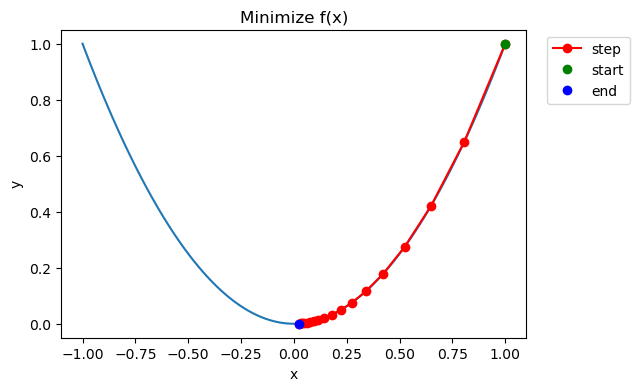

x  [1, 0.806, 0.6496360000000001, 0.5236066160000001, 0.4220269324960001, 0.3401537075917761, 0.27416388831897154, 0.22097609398509105, 0.17810673175198338, 0.1435540257920986, 0.11570454478843148, 0.09325786309947577, 0.07516583765817747, 0.06058366515249104, 0.04883043411290778, 0.03935732989500367, 0.03172200789537296, 0.025567938363670606]
y  [1, 0.6496360000000001, 0.42202693249600015, 0.2741638883189716, 0.1781067317519834, 0.11570454478843152, 0.0751658376581775, 0.04883043411290779, 0.03172200789537297, 0.020607758321118514, 0.013387541684698146, 0.008697029029880565, 0.00564990315085549, 0.0036703804833091574, 0.0023844112956550277, 0.0015489994164641497, 0.0010062857849141044, 0.0006537194721684592]


In [10]:
x_hist, y_hist = gradient_descent(
    x=1, 
    f=f, 
    f_prime=f_prime,
    verbose=False, # Set to True to see more details
    # TODO 2.6
    steps= 20000,
    #alpha= .1699999 #with steps 500, but x not passing
    #alpha = .5  with 10 steps works and passes code, but not smooth
    #alpha = 0.1  x not passing;  played with this for too long
    alpha = 0.097
)

# Plot the x^2 function
ax = plot_f(min_value=-np.max(x_hist), max_value=np.max(x_hist))
# Plot the history of x-y coordinates (i.e., steps taken)
ax.plot(x_hist, y_hist, 'ro-', label='step')
# Plot start position
ax.plot(x_hist[0], y_hist[0], 'go', label='start')
# Plot end position
ax.plot(x_hist[-1], y_hist[-1], 'bo', label='end');
ax.legend(bbox_to_anchor=(1.03, 1))
plt.show()
print("x ",x_hist)
print("y ",y_hist)

In [11]:
todo_check([
    ("x_hist[-1] <= 0.001", "Final x-coord is not near zero"),
    ("y_hist[-1] <= 0.001", "Final y-coord is not near zero"),
])

TodoCheckFailed: You passed 1/2 and FAILED the following code checks:

Check [1]: Failed
	Tip: Final x-coord is not near zero


# Least Mean Squares (LMS)
## Diabetes Dataset
This assignment will have you tackle the classical Diabetes dataset, where the goal is to predict the progression of diabetes one year after the baseline measurements. The Diabetes dataset is frequently used when first being introduced to regression tasks in machine learning. Below is a description of the dataset from [Scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset).

> The dataset contains 10 baseline features, such as age, sex, body mass index (BMI), average blood pressure, and six blood serum measurements. The target variable represents a quantitative measure of disease progression one year after baseline. This dataset provides a good example for testing regression models due to its small size, standardized features, and straightforward problem setup.

Thus, the goal of this data is a regression problem where you must predict a continuous value indicating the severity of diabetes progression for each patient.


## Data Loading

#### TODO 3 (5 points): Data Loading
Complete the TODO by loading the Diabetes dataset using Sklearn.

1. Import the `load_diabetes` function from `sklearn.datasets`.
<br><br>
2. Load the dataset by calling the `load_diabetes()` function and pass the argument(s) that satisfy the below descriptions. Store the output into `diabetes`.
    - Pass the argument that returns the data as a pandas DataFrame.
    - Pass the argument that returns the unscaled data (i.e., the data is not scaled).

In [12]:
# TODO 3.1
from sklearn.datasets import load_diabetes

# TODO 3.2
diabetes = load_diabetes(as_frame=True, scaled=False)


In [13]:
todo_check([
    ("isinstance(diabetes, sklearn.utils.Bunch)", "'diabetes' is not of type Bunch"),
    ("isinstance(diabetes.data, pd.DataFrame)", "diabetes.data is not a Pandas DataFrame. Make sure to pass the correct argument to load_diabetes()."),
    ("isinstance(diabetes.target, pd.Series)", "diabetes.target is not a Pandas series. Make sure to pass the correct argument to load_diabetes()."),
    ("np.isclose(diabetes.data['age'].mean(), 48.51809)", "diabetes.data values are incorrect. Make sure the data is unscaled."),
])

Your code PASSED all the code checks! 


Below, we have printed out the data and target values. Recall, `diabetes` is a Sklearn `Bunch` object.

In [14]:
diabetes.data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0
...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0


Looking at the data statistics, you should see that the scales (i.e., mean and STD) of each feature are different. **This time, you will correct the different scales using standardization!**

In [15]:
diabetes.data.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000


## Data Preprocessing



### Standardization
This new preprocessing step will be used to scale all the numerical features such that they all have the same scales. Recall that standardization transforms your data to have a zero mean and a standard deviation (STD) of 1 (i.e., unit variance). To standardize the data, you simply subtract each feature by its mean and divide by its STD as follows:

$$
\frac{\Xm - \vec{\mu}}{\vec{\sigma}},
$$

where $\Xm$ is the input data matrix, $\vec{\mu}$ (mu) is a vector of means for each feature, and $\vec{\sigma}$ (sigma) is a vector of STDs for each feature.

#### TODO 4 (10 points): Standardize Class

Complete the following `Standardize` class provided below.

**`fit()` TODOs**

1. Compute the mean and STD of each feature using the input data `X`. Store the output into the variables `self.mean` and `self.std`.
    1. Hint:  Make sure you are specifying the correct axis (see this [tutorial](https://www.sharpsightlabs.com/blog/numpy-axes-explained/) for more details about the NumPy's axis argument). You have to compute the mean and STD for EACH feature, not just for the entire matrix. 

**`transform()` TODOs**

2. Standardize the passed data `X` by implementing the standardization formula given above. Return the output.


In [16]:
class Standardize():
    """ Standize data based on mean and STD computed using training data

        Attributes:
            mean: Vector of means for each feature 

            std: Vector of STDs for each feature
            
    """
    def __init__(self):
        self.mean: np.ndarray = None
        self.std: np.ndarray = None
    
    def fit(self, X: np.ndarray) -> object:
        """ Computes the mean and std using the training data.

            Args:
                X: training data given as a matrix

            Return:
                Reference to object's instance
        """
        # TODO 4.1
        self.mean = np.mean(X, axis = 0)
        self.std = np.std(X, axis =0)
        
        return self
        
    def transform(self, X: np.ndarray) -> np.ndarray:
        """ Transforms the passed data using standardization based on the 
            precomputed mean and STD.

            Args:
                X: Data given as a matrix

            Returns:
                Standardized matrix of data
        """
        # TODO 4.2
        Standardize = (X - self.mean)/self.std
        return Standardize

In [17]:
def TEST_Standardize():
    X = diabetes.data.values  
    stand = Standardize()
    stand.fit(X)
    Xs = stand.transform(X)

    todo_check([
        ("Xs.shape == X.shape", "Xs shape is incorrect."),
        ("np.isclose(Xs.mean(axis=0).sum(), 0, rtol=0.01)", "Xs has potentially incorrect mean values."),
        ("np.isclose(Xs.std(axis=0).sum(), 10, rtol=0.01)", "Xs has potentially incorrect STD values."), 
    ], **locals())

TEST_Standardize()

Your code PASSED all the code checks! 


## Putting it all together

Recall, in order to prepare the data for linear regression, you will need to split the data and add the bias. Additionally, now you will standardize the data. Thus, it is time to combine all the data preprocessing steps (data splitting, standardization and add bias) into one function which returns the fully preprocessed data.


#### TODO 5 (10 points): get_preprocessed_data function

Complete the following the `get_preprocessed_data()` function for performing data preprocessing.

1. Call Sklearn's `train_test_split()` function such that the train set is 80% of the data and the test set is 20% of the data. Additionally, pass a seed of 42 for the random state. Store the output into `X_trn`, `X_tst`, `y_trn`, and `y_tst`.
    1. Hint: Be sure to pass the diabetes data/targets as NumPy arrays instead of a DataFrame/Series by using the `values` attribute or `to_numpy()` function. 
<br><br>
2. Create an instance of the `Standardize` class, compute the mean and STD using the training data, and then transform both the training and testing data. Store the output back inside `X_trn` and `X_tst`.
<br><br>
3. Add the bias to the first column of the training `X_trn` and testing `X_tst` data. Store the output back into `X_trn` and `X_tst`.

In [18]:
from sklearn.model_selection import  train_test_split

In [19]:
def get_preprocessed_data():
    """ Gets preprocessed data for training and testing

        Returns:
            A tuple of NumPy arrays where the first two indices 
            contain the training data and targets and the last two
            indicies contain the testing data and targets. Targets
            should be 2D column vectors.
    """
    # TODO 5.1
    X_trn, X_tst, y_trn, y_tst = train_test_split(diabetes.data.values,
                                                  diabetes.target.values, 
                                                  train_size = .80,
                                                  random_state = 42)
    

    # TODO 5.2
    stand = Standardize()
    stand.fit(X_trn)  #computer the mean and std

    X_trn = stand.transform(X_trn )  #standardizes 
    print(X_trn.shape)
    print("Training: ",X_trn)

    
    X_tst = stand.transform(X_tst)
    print(X_tst.shape)
    print("testing", X_tst)
    
    
    # TODO 5.3
    biasT = np.ones((len(X_trn),1))
    bias2 = np.ones((len(X_tst),1))

    X_trn = np.hstack((biasT, X_trn))
    X_tst = np.hstack((bias2, X_tst))
    

    # Reshape targets to be 2D column vectors
    return X_trn, y_trn.reshape(-1, 1), X_tst, y_tst.reshape(-1, 1)

In [20]:
#Run Code - delete later
'''
X_trn, X_tst, y_trn, y_tst = train_test_split(diabetes.data.values,
                                                  diabetes.target.values, 
                                                  train_size = .80,
                                                  random_state = 42)
    

# TODO 5.2
stand = Standardize()
stand.fit(X_trn)  #computer the mean and std

X_trn = stand.transform(X_trn )  #standardizes 
print(X_trn.shape)
print("Training: ",X_trn)

   
X_tst = stand.transform(X_tst)
print(X_tst.shape)
print("testing", X_tst)

# TODO 5.3
biasT = np.ones((len(X_trn),1))
bias2 = np.ones((len(X_tst),1))

#remember that hstack accepts a list or tuple. so either ([]) or (())
X_trn = np.hstack((biasT, X_trn))
X_tst = np.hstack((bias2, X_tst))

#X_trn = pd.concat(biasT, X_trn, axis = 1)
#X_tst = pd.concat(bias2, X_tst, axis = 1)'
'''


'\nX_trn, X_tst, y_trn, y_tst = train_test_split(diabetes.data.values,\n                                                  diabetes.target.values, \n                                                  train_size = .80,\n                                                  random_state = 42)\n    \n\n# TODO 5.2\nstand = Standardize()\nstand.fit(X_trn)  #computer the mean and std\n\nX_trn = stand.transform(X_trn )  #standardizes \nprint(X_trn.shape)\nprint("Training: ",X_trn)\n\n   \nX_tst = stand.transform(X_tst)\nprint(X_tst.shape)\nprint("testing", X_tst)\n\n# TODO 5.3\nbiasT = np.ones((len(X_trn),1))\nbias2 = np.ones((len(X_tst),1))\n\n#remember that hstack accepts a list or tuple. so either ([]) or (())\nX_trn = np.hstack((biasT, X_trn))\nX_tst = np.hstack((bias2, X_tst))\n\n#X_trn = pd.concat(biasT, X_trn, axis = 1)\n#X_tst = pd.concat(bias2, X_tst, axis = 1)\'\n'

In [21]:
def TEST_get_preprocessed_data():
    X_trn, y_trn, X_tst, y_tst = get_preprocessed_data()
    
    print(f"X_trn shape: {X_trn.shape}")
    print(f"y_trn shape: {y_trn.shape}")
    print(f"X_tst shape: {X_tst.shape}")
    print(f"y_tst shape: {y_tst.shape}")
    print(f"X_trn means:\n{X_trn.mean(axis=0)}")
    print(f"X_tst means:\n{X_tst.mean(axis=0)}")

    todo_check([
        # Split tests
        ("isinstance(X_trn, np.ndarray)", "X_trn must be a NumPy array."),
        ("isinstance(X_tst, np.ndarray)", "X_tst must be a NumPy array."),
        ("isinstance(y_trn, np.ndarray)", "y_trn must be a NumPy array."),
        ("isinstance(y_tst, np.ndarray)", "y_tst must be a NumPy array."),
        ("X_trn.shape == (353, 11)", "X_trn does not seem to have the right shape, expected (353, 11)."),
        ("X_tst.shape == (89, 11)", "X_tst does not seem to have the right shape, expected (89, 11)."),
        ("len(y_trn) == 353", "X_trn has incorrect number of data samples."),
        ("len(y_tst) == 89", "X_tst has incorrect number of data samples."),
        # Standardization Tests
        ('np.isclose(X_trn[:, 1:].mean(axis=0).sum(), 0, rtol=0.01)', 'X_trn has potentially incorrect mean values.'),
        ('np.isclose(X_trn[:, 1:].std(axis=0).sum(), 10, rtol=0.01)', 'X_trn has potentially incorrect std values.'),  
        ('np.isclose(X_tst[:, 1:].mean(axis=0).sum(), -0.5910588788559706, rtol=0.01)', 'X_tst has potentially incorrect mean values.'),  
        ('np.isclose(X_tst[:, 1:].std(axis=0).sum(), 9.947952920828264, rtol=0.01)', 'X_tst has potentially incorrect std values.'), 
        # Bias Tests
        ("(X_trn[:, 0] == 1).all()", "The 1st column of `X_trn` does not seem to be the bias term (i.e., full of 1s)."),
        ("(X_tst[:, 0] == 1).all()", "The 1st column of `X_tst` does not seem to be the bias term (i.e., full of 1s)."),
    ], **locals())

TEST_get_preprocessed_data()

(353, 10)
Training:  [[ 1.49836523  1.06136988  0.21990201 ...  0.71103773  0.54748197
  -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 ...  1.4842858  -0.01975653
   0.36723647]
 [ 0.08518241 -0.94217861  1.01898711 ... -0.06221033  0.3312366
  -0.31866022]
 ...
 [ 0.63475351 -0.94217861 -0.46502808 ... -0.83545839 -0.25375196
  -0.06144896]
 [-0.30736838 -0.94217861 -0.53352109 ... -0.06221033 -0.83072436
  -0.83308273]
 [-2.03459183 -0.94217861  0.56236706 ... -0.83545839 -0.13312789
  -0.06144896]]
(89, 10)
testing [[ 9.48794133e-01 -9.42178611e-01 -1.68225039e-01 -3.54924745e-01
   2.63158584e+00  2.64916600e+00  4.29486950e-01  7.11037735e-01
   6.53600610e-01 -1.47186045e-01]
 [ 1.96942617e+00 -9.42178611e-01  7.45015079e-01  4.27541124e-01
  -5.11434037e-01 -3.33282444e-01  3.76314490e-02 -8.35458386e-01
  -4.96908703e-01 -4.90134388e-01]
 [ 1.34134492e+00  1.06136988e+00 -1.22563033e-01 -2.83791484e-01
   2.17022512e+00  1.04272578e+00  1.21319795e+00 -6.22103255e-02
   1.

## Batching

#### TODO 6 (10 points): get_batches

Complete the TODO by finishing the `get_batches()` function

1. Generate the indices of the data by using `np.arange()` and the passed variable `data_len`. Store the output into `indices`.
<br><br>
2. Randomize the indices by using the `np.random.shuffle()` function.
<br><br>
3. Using `indices`, generate a list of NumPy arrays where each element corresponds to a batch of indices of the size `batch_size`. For example, if `batch_size=32` the first 32 samples in `indices` corresponds to the first batch of indices and the next 32 samples corresponds to the second batch of indices. If the last batch is less than 32 samples (e.g., 7 samples), this batch should still be added. Store the output in `batches`.
    1. Hint: Loop-over the `indices` iterating by `batch_size` and slicing an array of size `batch_size` and appending it to the list `batches`. Trying using Python's `range()` built-in function to iterate by the batch size.
    2. Hint: This can be done using a very simple for-loop (one line if very efficient).

In [22]:
def get_batches(
    data_len: int, 
    batch_size: int = 32,
) -> List[np.ndarray]:
    """ Generates mini-batches based on the data indices
        
        Args:
            data_len: Length of the data or number of data samples 
                in the data. This is used to generate the indices of
                the data.
            
            batch_size: Size of each mini-batch where the last mini-batch
                might be smaller than the rest if the batch_size does not 
                evenly divide the data length.

        Returns:
            A list of NumPy array's holding the indices of batches
    """
    # TODO 6.1
    # https://numpy.org/doc/stable/reference/generated/numpy.arange.html
    indices = np.arange(data_len)   #creates an array of length data_length
    

    # TODO 6.2
    # https://numpy.org/doc/stable/reference/random/generated/numpy.random.shuffle.html

    np.random.shuffle(indices)  # shuffles indices in place; no reason to store value again
    

    # TODO 6.3
    # https://docs.python.org/3/library/functions.html
    # range(batch_size)  creates 0 to 31
    '''
    Using `indices`, generate a list of NumPy arrays where each element corresponds to a batch of indices of the size `batch_size`. For example, if `batch_size=32` the first 32 samples in `indices` corresponds
    to the first batch of indices and the next 32 samples corresponds to the second batch of indices. If the last batch is less than 32 samples (e.g., 7 samples), this batch should still be added. Store the output in `batches`.
    1. Hint: Loop-over the `indices` iterating by `batch_size` and slicing an array of size `batch_size` and appending it to the list `batches`. Trying using Python's `range()` built-in function to iterate by the batch size.
    2. Hint: This can be done using a very simple for-loop (one line if very efficient).

    RANGE
    Start: The first number in the sequence (default is 0).
    Stop: The sequence will go up to, but not include, this number.
    Step: The difference between each number in the sequence (default is 1).

    '''
    batches = []

    for i in range(0, len(indices), batch_size):
        batch = indices[i:i + batch_size]
        batches.append(batch)

    return batches

In [23]:
def TEST_get_batches():
    X_trn, _, _, _, = get_preprocessed_data()
    
    print("{:-^50}".format("Mini-Batches"))
    np.random.seed(0)
    mini_batches = get_batches(len(X_trn), batch_size=30)
    print(f"Length of mini-batches: {len(mini_batches[0])}")
    print(f"Length of last mini-batches: {len(mini_batches[-1])}")
    print(f"Number of mini-batches: {len(mini_batches)}")
    print(f"Minibatch example:\n{mini_batches[0]}")
    
    print("{:-^50}".format("Online Batches"))
    np.random.seed(0)
    online_batches = get_batches(len(X_trn), batch_size=1)
    print(f"Number of online-batches: {len(online_batches)}")
    print(f"Online batch example:\n{online_batches[0]}")
    
    print("{:-^50}".format("Batches"))
    np.random.seed(0)
    batches =get_batches(len(X_trn), batch_size=len(X_trn))
    print(f"Number of batches: {len(batches)}")
    print(f"Batch example:\n{batches[0]}")
    print("-"*50)
    
    todo_check([
        # Mini-Batch
        ("mini_batches[0][-1] == 100", 'The first minibatch\'s last sample should have the index value 100.'),
        ("len(mini_batches[0]) == 30", "mini_batches has the wrong length for the first batch."),
        ("len(mini_batches) == 12", "mini_batches has the wrong number of batches."),
        ("len(mini_batches[-1]) == 23", "mini_batches last batch has the wrong length."),
        # Online-Batch
        ("online_batches[0][-1] == 6", 'The first online sample should have the index value 6.'),
        ("len(online_batches) == 353", "online_batches has the wrong number of batches."),
        ("len(online_batches[0]) == 1", "The first online batch should have a single sample."),
        # Full Batch
        ("batches[0][-1] == 172", 'batches last sample should have the index value 172.'),
        ("len(batches) == 1", "batches has the wrong number of batches."),
        ("len(batches[0]) == len(X_trn)", "The single batch should contain all training samples."),
    ], **locals())

TEST_get_batches()

(353, 10)
Training:  [[ 1.49836523  1.06136988  0.21990201 ...  0.71103773  0.54748197
  -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 ...  1.4842858  -0.01975653
   0.36723647]
 [ 0.08518241 -0.94217861  1.01898711 ... -0.06221033  0.3312366
  -0.31866022]
 ...
 [ 0.63475351 -0.94217861 -0.46502808 ... -0.83545839 -0.25375196
  -0.06144896]
 [-0.30736838 -0.94217861 -0.53352109 ... -0.06221033 -0.83072436
  -0.83308273]
 [-2.03459183 -0.94217861  0.56236706 ... -0.83545839 -0.13312789
  -0.06144896]]
(89, 10)
testing [[ 9.48794133e-01 -9.42178611e-01 -1.68225039e-01 -3.54924745e-01
   2.63158584e+00  2.64916600e+00  4.29486950e-01  7.11037735e-01
   6.53600610e-01 -1.47186045e-01]
 [ 1.96942617e+00 -9.42178611e-01  7.45015079e-01  4.27541124e-01
  -5.11434037e-01 -3.33282444e-01  3.76314490e-02 -8.35458386e-01
  -4.96908703e-01 -4.90134388e-01]
 [ 1.34134492e+00  1.06136988e+00 -1.22563033e-01 -2.83791484e-01
   2.17022512e+00  1.04272578e+00  1.21319795e+00 -6.22103255e-02
   1.

## Metrics

Below are the metrics you will be using. Do not override these function names!

In [24]:
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_squared_error as mse

## Coding LMS

Finally, it is time to practice *Least Mean Squares (LMS)*. Recall that the following equation(s) is the update rule using the average gradient over a batch, which aims to slowly moving the weights towards achieving the smallest training error and optimal weights. 

We can write this equation(s) in multiple ways depending on the assumed shapes of $\xv$, $\Xm$, $\yv$ and $\wv$. Depending on the assumptions made, the algorithm can be either easier or harder to convert to code. Regardless of the equation, $B$ denotes the batch size, subscript $_b$ denotes the data indexed at a particular batch, subscript $_{old}$ denotes the old weights before being updated, subscript $_{new}$ denotes the new weights after being updated, $N$ denotes number of data samples, and $M$ denotes number of features.


The first set of equations assume that $\wv_{old}$ is the current weights given as a row vector, $\Xm_b$ is a matrix containing the data samples for the batch with shape $(B, M)$, and $\yv_b$ is a row vector containing the labels for the batch. 
$$
\begin{align}
\wv_{new} &=  \wv_{old} - \alpha \nabla J(\wv_{old}) \\
% &= \wv_{old} - \alpha \Big [ \frac{1}{B}\sum_{m=0}^B \Big( {\wv_{old}} \xv_m^\top - y_m \Big) \odot \xv_m \Big ] \\
% &= \wv_{old} - \alpha \Big [ \frac{1}{B}\sum_{m=0}^B \Big( \hat{y}_m - y_m \Big) \odot \xv_m \Big ] \\
&= \wv_{old} - \alpha  \frac{1}{B} \Big [ \Big( {\wv_{old}} \Xm_b^\top - \yv_b \Big) \Xm_b \Big ].
\end{align}
$$

The second set of equations assume that $\wv_{old}$ is the current weights given as a column vector, $\Xm_b$ is a matrix containing the data samples for the batch with shape $(B, M)$, and $\yv_b$ is a column vector containing the labels for the batch. 
$$
\begin{align}
\wv_{new} &=  \wv_{old} - \alpha \nabla J(\wv_{old}) \\
% &= \wv_{old} - \alpha \Big [ \frac{1}{B}\sum_{m=0}^B  \xv_m^\top \odot \Big({ \xv_m \wv_{old}} - y_m \Big) \Big ] \\
% &= \wv_{old} - \alpha \Big [ \frac{1}{B}\sum_{m=0}^B \xv_m^\top \odot \Big( \hat{y}_m - y_m \Big) \Big ] \\
&= \wv_{old} - \alpha \frac{1}{B} \Big [ \Xm_b^\top \Big( \Xm_b {\wv_{old}}  - \yv_b \Big) \Big ]
\end{align}
$$

#### TODO 7 (30 points): LeastMeanSquares

Complete the TODO by finishing the `LeastMeanSqaures` class using the second set of equations.

**`fit()` TODOs**

1. Randomly initialize the weights `self.w` using the `np.random.rand()` function. The weights should be a 2D column vector $(M, 1)$ (if set to a 1D or row vector, then the first set of equation(s) would need to be used). Store the output into the class variable `self.w`.

2. Fetch the batches indices by calling the  `get_batches()`function and passing its corresponding arguments. Store the output in `batches`.
    1. Hint: Pass the arguments that correspond to the following descriptions:
        1. Number of data samples in `X`.
        2. The batch size (refer to the `LeastMeanSquares` class variables).
 
3. Compute the mean gradient for the current the batch. Do so by indexing the training data `X` and `y` using the current batch indices `b`. Store the output into `mean_grad`.
    1. Hint: $\Xm_b$ refers to the data $X$ indexed at the batch indices $b$ where $b$ corresponds directly to `b` in code. 
    2. Hint: `mean_grad` will need to be the same shape as `self.w`.

4. Update the weights `self.w` using the gradient update equations and the mean gradient `mean_grad`. Store the output back into `self.w`.

**`predict()` TODOs**

5. Compute the predictions by taking the linear combination between the weights and passed data. Return the predictions as a 2D column vector.

In [25]:
class LeastMeanSquares():
    """ Performs regression using least mean squares (gradient descent)
    
        Attributes:

            alpha: learning rate or step size
                
            batch_size: Size of mini-batches for mini-batch gradient
                descent.
            
            epochs: Number of epochs to run for mini-batch
                gradient descent
                
            seed: Seed to be used for NumPy's RandomState class
                or universal seed np.random.seed() function.

            w: 2D column vector of weights 

            trn_error: Stores the training error for each epoch.
    """

    def __init__(
        self, 
        alpha: float ,
        batch_size: int,
        seed: int = 0,
        epochs: int = 1,
    ):
        self.alpha = alpha
        self.batch_size = batch_size
        self.epochs = epochs
        self.seed = seed
        self.w: np.ndarray = None
        self.trn_error: list = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> object:
        """ Train LMS to learn weights

            Args:
                X: Training data given as a matrix

                y: Training labels given as a 2D column vector
                
            Returns:
                The class's own object reference. 
        """
        # Set seed for reproducibility
        np.random.seed(self.seed)
        # Track training error
        self.trn_error = []
        
        # TODO 7.1
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html
        self.w = np.random.rand(X.shape[1], 1)
        #print("shape self.w ",self.w.shape)
        #print("shape X ", X.shape)
        #print("TODO 7.1")
        
        # Loop over training epochs
        for e in range(self.epochs):
            # TODO 7.2
            batches = []
            #print("TODO 7.2 - in for loop")

            batches = get_batches(len(X),self.batch_size)
            #print("TODO 7.2")
            #print(batches)
            #print("number of batches ", len(batches))
            
            # Loop over batched data indices
            for b in batches:
                # TODO 7.3

                X_b = X[b]
                y_b = y[b]
                #print("TODO 7.3")
                #print("shape x_b ", X_b.shape)
                #print("shape y_b ", y_b.shape)


                # gradient: 
                mean_grad = (1 / (X_b.shape[0])) * (X_b.T @ (X_b @ self.w - y_b))
                #print("TODO 7.3  mean_gradiant")
                #print("length b ", (X.shape[0]))

                # TODO 7.4
                self.w -= self.alpha * mean_grad
                #print("TODO 7.4")

            # Compute training error for current epoch
            preds = self.predict(X)
            trn_error = rmse(y, preds)
            self.trn_error.append(trn_error)
            
        return self
        
    def predict(self, X: np.ndarray) -> np.ndarray:
        """ Make predictions using learned weights

            Args:
                X: Data given as a matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
         # TODO 7.5
        
        return X @ self.w

Dummy X shape: (100, 2)
Dummy y shape: (100, 1)
Dummy y_hat shape: (100, 1)
Dummy Train MSE: 0.09674451861759695
Dummy Train RMSE: 0.3110378089840477
Dummy Final weights: [2.38788598 0.98483949]


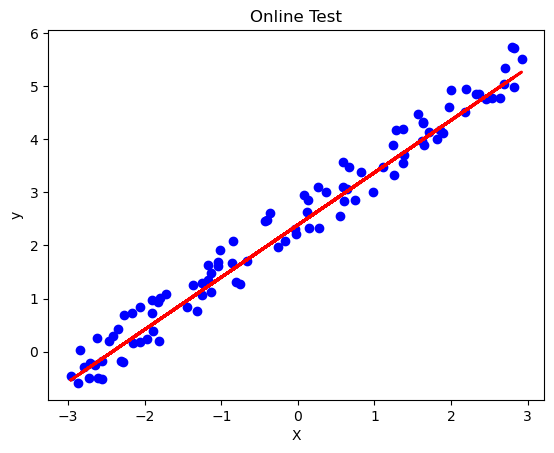

In [26]:
#TEST Code
m = 100
rng = np.random.RandomState(42)
X = 6 * rng.rand(m, 1) - 3
y = (2 + X) + rng.rand(m, 1)
X1 = np.hstack([np.ones((len(X), 1)), X])
print(f"Dummy X shape: {X1.shape}")
print(f"Dummy y shape: {y.shape}")

lms = LeastMeanSquares(
alpha=.001, 
batch_size=1, 
epochs=30,
seed=42
)
lms.fit(X1, y)
y_hat = lms.predict(X1)
print(f"Dummy y_hat shape: {y_hat.shape}")
trn_mse = mse(y, y_hat)
trn_rmse = rmse(y, y_hat)
print(f"Dummy Train MSE: {trn_mse}")
print(f"Dummy Train RMSE: {trn_rmse}")
print(f"Dummy Final weights: {lms.w.flatten()}")
plt.title("Online Test")
plt.plot(X, y, 'ob')
plt.plot(X, y_hat, '-r', linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.show()


##### Online Training Test

Test `LeastMeanSquares` using batch size of 1.

Dummy X shape: (100, 2)
Dummy y shape: (100, 1)
Dummy y_hat shape: (100, 1)
Dummy Train MSE: 0.09674451861759695
Dummy Train RMSE: 0.3110378089840477
Dummy Final weights: [2.38788598 0.98483949]


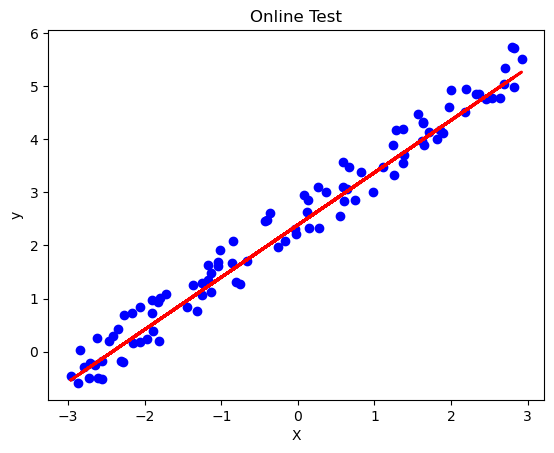

Your code PASSED all the code checks! +10 points


In [27]:
def TEST_online_LeastMeanSquares():    
    m = 100
    rng = np.random.RandomState(42)
    X = 6 * rng.rand(m, 1) - 3
    y = (2 + X) + rng.rand(m, 1)
    X1 = np.hstack([np.ones((len(X), 1)), X])
    print(f"Dummy X shape: {X1.shape}")
    print(f"Dummy y shape: {y.shape}")
    
    lms = LeastMeanSquares(
        alpha=.001, 
        batch_size=1, 
        epochs=30,
        seed=42
    )
    lms.fit(X1, y)
    y_hat = lms.predict(X1)
    print(f"Dummy y_hat shape: {y_hat.shape}")
    trn_mse = mse(y, y_hat)
    trn_rmse = rmse(y, y_hat)
    print(f"Dummy Train MSE: {trn_mse}")
    print(f"Dummy Train RMSE: {trn_rmse}")
    print(f"Dummy Final weights: {lms.w.flatten()}")
    plt.title("Online Test")
    plt.plot(X, y, 'ob')
    plt.plot(X, y_hat, '-r', linewidth=2)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show();
    
    todo_check([
        ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
        ("np.isclose(trn_rmse, 0.31103, rtol=.01)", "Train RMSE value is potentially incorrect!"),
        ("np.all(np.isclose(lms.w.flatten(), [2.38788, 0.98483],  rtol=.1))", 'lms.w values are possibly incorrect!')
    ], success_msg="+10 points", **locals())

TEST_online_LeastMeanSquares()

##### Minibatch Training Test

Test `LeastMeanSquares` using minibatch size 32. 

Dummy X shape: (100, 2)
Dummy y shape: (100, 1)
Dummy y_hat shape: (100, 1)
Dummy Train MSE: 0.08825838078829831
Dummy Train RMSE: 0.29708312100874784
Dummy Final weights: [2.5089227  0.96361201]


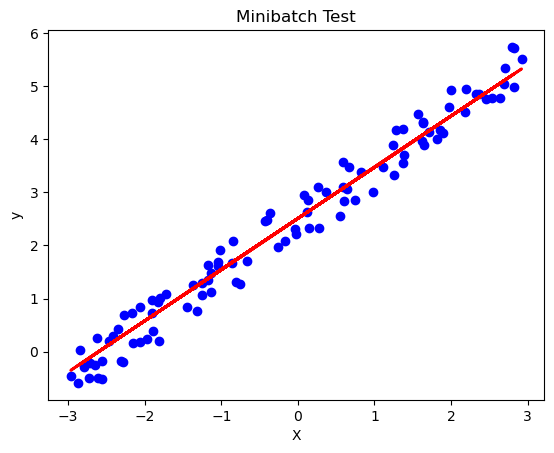

Your code PASSED all the code checks! +10 points


In [28]:
def TEST_minibatch_LeastMeanSquares():    
    m = 100
    rng = np.random.RandomState(42)
    X = 6 * rng.rand(m, 1) - 3
    y = (2 + X) + rng.rand(m, 1)
    X1 = np.hstack([np.ones((len(X), 1)), X])
    print(f"Dummy X shape: {X1.shape}")
    print(f"Dummy y shape: {y.shape}")
    
    lms = LeastMeanSquares(
        alpha=.1, 
        batch_size=32, 
        epochs=30,
        seed=42
    )
    lms.fit(X1, y)
    y_hat = lms.predict(X1)
    print(f"Dummy y_hat shape: {y_hat.shape}")
    trn_mse = mse(y, y_hat)
    trn_rmse = rmse(y, y_hat)
    print(f"Dummy Train MSE: {trn_mse}")
    print(f"Dummy Train RMSE: {trn_rmse}")
    print(f"Dummy Final weights: {lms.w.flatten()}")
    plt.title("Minibatch Test")
    plt.plot(X, y, 'ob')
    plt.plot(X, y_hat, '-r', linewidth=2)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show();
    
    todo_check([
        ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
        ("np.isclose(trn_rmse, 0.29708, rtol=.01)", "Train RMSE value is potentially incorrect!"),
        ("np.all(np.isclose(lms.w.flatten(), [2.50892, 0.963612],  rtol=.1))", 'lms.w values are possibly incorrect!')
    ], success_msg="+10 points", **locals())

TEST_minibatch_LeastMeanSquares()

##### Batch Training Test

Test `LeastMeanSquares` using batch gradient descent.

Dummy X shape: (100, 2)
Dummy y shape: (100, 1)
Dummy y_hat shape: (100, 1)
Dummy Train MSE: 0.09371584712221655
Dummy Train RMSE: 0.3061304413517489
Dummy Final weights: [2.40286248 0.98677294]


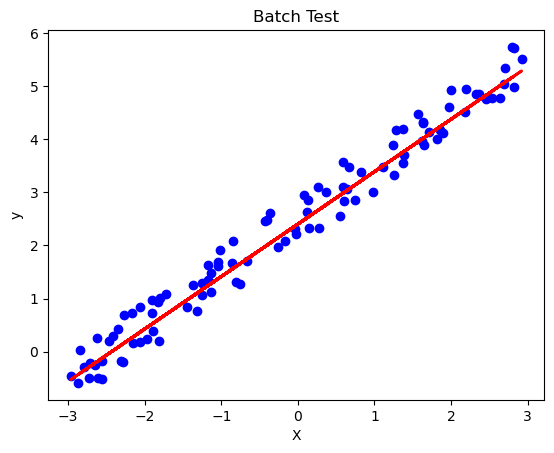

Your code PASSED all the code checks! +10 points


In [29]:
def TEST_batch_LeastMeanSquares():    
    m = 100
    rng = np.random.RandomState(42)
    X = 6 * rng.rand(m, 1) - 3
    y = (2 + X) + rng.rand(m, 1)
    X1 = np.hstack([np.ones((len(X), 1)), X])
    print(f"Dummy X shape: {X1.shape}")
    print(f"Dummy y shape: {y.shape}")
    
    lms = LeastMeanSquares(
        alpha=.1, 
        batch_size=len(X), 
        epochs=30,
        seed=42
    )
    lms.fit(X1, y)
    y_hat = lms.predict(X1)
    print(f"Dummy y_hat shape: {y_hat.shape}")
    trn_mse = mse(y, y_hat)
    trn_rmse = rmse(y, y_hat)
    print(f"Dummy Train MSE: {trn_mse}")
    print(f"Dummy Train RMSE: {trn_rmse}")
    print(f"Dummy Final weights: {lms.w.flatten()}")
    plt.title("Batch Test")
    plt.plot(X, y, 'ob')
    plt.plot(X, y_hat, '-r', linewidth=2)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show();
    
    todo_check([
        ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
        ("np.isclose(trn_rmse, .30613, rtol=.01)", "Train RMSE value is potentially incorrect!"),
        ("np.all(np.isclose(lms.w.flatten(), [2.40286, 0.98677],  rtol=.1))", 'lms.w values are possibly incorrect!')
    ], success_msg="+10 points", **locals())
    
TEST_batch_LeastMeanSquares()

## Diabetes Progression Prediction with LMS

#### TODO 8 (15 points): Training and Evaluating LMS

Complete the code below for training the `LeastMeanSquares` using the diabetes dataset. To pass the TODO check(s) you will need to reduce the RMSE below multiple thresholds. For each TODO check that you pass, points will be awarded. Do so by experimenting with various hyperparameters (i.e., initialization arguments) for `LeastMeanSquares`.

1. Initialize `LeastMeanSquares` by passing the required arguments. You will need to test various different combinations of arguments. Store the output into `lms`.
    1. Hint: Using a larger batch size can decrease the time it takes for the algorithm to run and can allow for a larger learning rate.
    2. Hint: Using a smaller batch size can increase the time it takes for the algorithm to run and often requires much smaller learning rates.
    3. Hint: Seed will change the random weight initialization and the random order of the batches for each epoch.
    4. **WARNING: Many epochs and a small batch size will greatly increase the time it takes for the algorithm to run! Avoid this!**
<br><br>
2. Train the LMS algorithm using the training data.
<br><br>
3. Compute the **training** predictions, MSE, and RMSE. Print out the MSE and RMSE values to see the final training score.
    1. Hint: It can be helpful to print out the MSE and RMSE values to see the final training scores. 
<br><br>
4. Compute the **testing** predictions, MSE, and RMSE.
    1. Hint: It can be helpful to print out the MSE and RMSE values to see the final testing scores.
  
**Tips**
- Uncomment the code marked as `### Plotting Code ###` to plot the learning curve (i.e., training error after each epoch finishes training). This can help you select the best hyperparameters!


(353, 10)
Training:  [[ 1.49836523  1.06136988  0.21990201 ...  0.71103773  0.54748197
  -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 ...  1.4842858  -0.01975653
   0.36723647]
 [ 0.08518241 -0.94217861  1.01898711 ... -0.06221033  0.3312366
  -0.31866022]
 ...
 [ 0.63475351 -0.94217861 -0.46502808 ... -0.83545839 -0.25375196
  -0.06144896]
 [-0.30736838 -0.94217861 -0.53352109 ... -0.06221033 -0.83072436
  -0.83308273]
 [-2.03459183 -0.94217861  0.56236706 ... -0.83545839 -0.13312789
  -0.06144896]]
(89, 10)
testing [[ 9.48794133e-01 -9.42178611e-01 -1.68225039e-01 -3.54924745e-01
   2.63158584e+00  2.64916600e+00  4.29486950e-01  7.11037735e-01
   6.53600610e-01 -1.47186045e-01]
 [ 1.96942617e+00 -9.42178611e-01  7.45015079e-01  4.27541124e-01
  -5.11434037e-01 -3.33282444e-01  3.76314490e-02 -8.35458386e-01
  -4.96908703e-01 -4.90134388e-01]
 [ 1.34134492e+00  1.06136988e+00 -1.22563033e-01 -2.83791484e-01
   2.17022512e+00  1.04272578e+00  1.21319795e+00 -6.22103255e-02
   1.

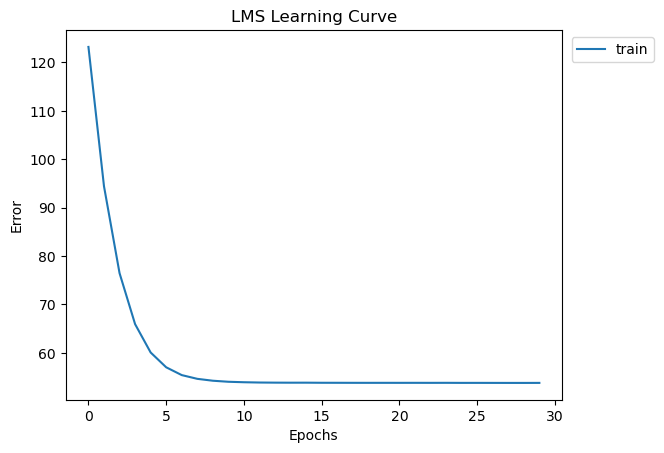

In [30]:
# Get training and testing data
X_trn, y_trn, X_tst, y_tst = get_preprocessed_data()

# TODO 8.1
lms = LeastMeanSquares(
        alpha=.001, 
        batch_size=1, 
        epochs=30,
        seed=42
    )


# TODO 8.2
lms.fit(X_trn, y_trn)
y_hat = lms.predict(X_trn)

y_hat_tst = lms.predict(X_tst)

# TODO 8.3
# Compute training predictions and metrics
trn_mse = mse(y_trn, y_hat)
trn_rmse = rmse(y_trn, y_hat)
print(f"Train MSE: {trn_mse}")
print(f"Train RMSE: {trn_rmse}")
print(f"Final weights: {lms.w.flatten()}")

# TODO 8.4
# Compute testing predictions and metrics
tst_mse = mse(y_tst, y_hat_tst)
tst_rmse = rmse(y_tst, y_hat_tst)
print(f"Test MSE: {tst_mse}")
print(f"Test RMSE: {tst_rmse}")
print(f"Final weights: {lms.w.flatten()}")

# ## Plotting Code ###
plt.plot(lms.trn_error, label='train')
plt.title("LMS Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend(bbox_to_anchor=(1.2, 1.00))
plt.show()

In [31]:
def easy_check():
    _, _, X_tst, y_tst = get_preprocessed_data()
    todo_check([
        ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
        ("rmse(y_tst, lms.predict(X_tst)) <= 58", "RMSE was not less than or equal to 58"),
    ],success_msg="+4 points")
easy_check()

(353, 10)
Training:  [[ 1.49836523  1.06136988  0.21990201 ...  0.71103773  0.54748197
  -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 ...  1.4842858  -0.01975653
   0.36723647]
 [ 0.08518241 -0.94217861  1.01898711 ... -0.06221033  0.3312366
  -0.31866022]
 ...
 [ 0.63475351 -0.94217861 -0.46502808 ... -0.83545839 -0.25375196
  -0.06144896]
 [-0.30736838 -0.94217861 -0.53352109 ... -0.06221033 -0.83072436
  -0.83308273]
 [-2.03459183 -0.94217861  0.56236706 ... -0.83545839 -0.13312789
  -0.06144896]]
(89, 10)
testing [[ 9.48794133e-01 -9.42178611e-01 -1.68225039e-01 -3.54924745e-01
   2.63158584e+00  2.64916600e+00  4.29486950e-01  7.11037735e-01
   6.53600610e-01 -1.47186045e-01]
 [ 1.96942617e+00 -9.42178611e-01  7.45015079e-01  4.27541124e-01
  -5.11434037e-01 -3.33282444e-01  3.76314490e-02 -8.35458386e-01
  -4.96908703e-01 -4.90134388e-01]
 [ 1.34134492e+00  1.06136988e+00 -1.22563033e-01 -2.83791484e-01
   2.17022512e+00  1.04272578e+00  1.21319795e+00 -6.22103255e-02
   1.

In [32]:
def medium_check():
    _, _, X_tst, y_tst = get_preprocessed_data()
    todo_check([
        ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
        ("rmse(y_tst, lms.predict(X_tst)) <= 56", "RMSE was not less than or equal to 56"),
    ],success_msg="+5 points")
medium_check()

(353, 10)
Training:  [[ 1.49836523  1.06136988  0.21990201 ...  0.71103773  0.54748197
  -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 ...  1.4842858  -0.01975653
   0.36723647]
 [ 0.08518241 -0.94217861  1.01898711 ... -0.06221033  0.3312366
  -0.31866022]
 ...
 [ 0.63475351 -0.94217861 -0.46502808 ... -0.83545839 -0.25375196
  -0.06144896]
 [-0.30736838 -0.94217861 -0.53352109 ... -0.06221033 -0.83072436
  -0.83308273]
 [-2.03459183 -0.94217861  0.56236706 ... -0.83545839 -0.13312789
  -0.06144896]]
(89, 10)
testing [[ 9.48794133e-01 -9.42178611e-01 -1.68225039e-01 -3.54924745e-01
   2.63158584e+00  2.64916600e+00  4.29486950e-01  7.11037735e-01
   6.53600610e-01 -1.47186045e-01]
 [ 1.96942617e+00 -9.42178611e-01  7.45015079e-01  4.27541124e-01
  -5.11434037e-01 -3.33282444e-01  3.76314490e-02 -8.35458386e-01
  -4.96908703e-01 -4.90134388e-01]
 [ 1.34134492e+00  1.06136988e+00 -1.22563033e-01 -2.83791484e-01
   2.17022512e+00  1.04272578e+00  1.21319795e+00 -6.22103255e-02
   1.

In [33]:
def hard_check():
    _, _, X_tst, y_tst = get_preprocessed_data()
    todo_check([
        ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
        ("rmse(y_tst, lms.predict(X_tst)) <= 54", "RMSE was not less than or equal to 54"),
    ],success_msg="+6 points")
hard_check()

(353, 10)
Training:  [[ 1.49836523  1.06136988  0.21990201 ...  0.71103773  0.54748197
  -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 ...  1.4842858  -0.01975653
   0.36723647]
 [ 0.08518241 -0.94217861  1.01898711 ... -0.06221033  0.3312366
  -0.31866022]
 ...
 [ 0.63475351 -0.94217861 -0.46502808 ... -0.83545839 -0.25375196
  -0.06144896]
 [-0.30736838 -0.94217861 -0.53352109 ... -0.06221033 -0.83072436
  -0.83308273]
 [-2.03459183 -0.94217861  0.56236706 ... -0.83545839 -0.13312789
  -0.06144896]]
(89, 10)
testing [[ 9.48794133e-01 -9.42178611e-01 -1.68225039e-01 -3.54924745e-01
   2.63158584e+00  2.64916600e+00  4.29486950e-01  7.11037735e-01
   6.53600610e-01 -1.47186045e-01]
 [ 1.96942617e+00 -9.42178611e-01  7.45015079e-01  4.27541124e-01
  -5.11434037e-01 -3.33282444e-01  3.76314490e-02 -8.35458386e-01
  -4.96908703e-01 -4.90134388e-01]
 [ 1.34134492e+00  1.06136988e+00 -1.22563033e-01 -2.83791484e-01
   2.17022512e+00  1.04272578e+00  1.21319795e+00 -6.22103255e-02
   1.